In [2]:
import os
import json
import sys

import pandas as pd
import numpy as np

import matplotlib.pyplot as plt
import seaborn as sns


sns.set_theme(style="darkgrid")
plt.rcParams["figure.figsize"] = (14, 5)
plt.rcParams["figure.dpi"] = 120

## 1. Loading data 

In [3]:
sys.path.append(os.path.abspath(".."))
from config.settings import MERGED_JSON_PATH

df = pd.DataFrame(json.load(open(MERGED_JSON_PATH)))
df["time"] = pd.to_datetime(df["time"])
df.set_index('time', inplace=True)
df.sort_index(inplace=True)

print(f"Total records: {len(df)}")
print(f"Data Range: {df.index.min()} to {df.index.max()}")
print(f"Total days : {len(df) / 24:.0f}")
print(f"Columns: {list(df.columns)}")

Total records: 12360
Data Range: 2025-01-01 00:00:00 to 2026-05-30 23:00:00
Total days : 515
Columns: ['temperature', 'humidity', 'rain', 'wind_speed', 'wind_direction', 'pressure', 'weather_code', 'pm2_5', 'pm10', 'no2', 'so2', 'o3', 'co', 'aqi']


## 2. Data Overview & Columns Data Types

In [4]:
df.head(5)

,temperature,humidity,rain,wind_speed,wind_direction,pressure,weather_code,pm2_5,pm10,no2,so2,o3,co,aqi
time,,,,,,,,,,,,,,
2025-01-01 00:00:00,14.9,63,0.0,11.0,360,1015.7,0,34.2,34.5,14.5,8.1,58.0,857.0,114
2025-01-01 01:00:00,14.4,65,0.0,11.4,5,1015.2,0,34.5,34.8,11.3,8.0,62.0,824.0,111
2025-01-01 02:00:00,14.0,65,0.0,12.1,7,1014.8,0,35.4,35.7,8.6,8.1,65.0,800.0,108
2025-01-01 03:00:00,13.6,66,0.0,12.7,7,1014.7,3,37.1,37.5,6.8,8.4,67.0,768.0,105
2025-01-01 04:00:00,13.2,66,0.0,13.4,8,1014.5,3,39.5,39.9,5.5,8.9,68.0,745.0,102


In [5]:
df.tail(5)

,temperature,humidity,rain,wind_speed,wind_direction,pressure,weather_code,pm2_5,pm10,no2,so2,o3,co,aqi
time,,,,,,,,,,,,,,
2026-05-30 19:00:00,35.7,50,0.0,21.0,215,996.2,0,31.7,88.7,3.5,6.6,91.0,214.0,79
2026-05-30 20:00:00,33.3,62,0.0,20.2,214,997.1,0,28.9,78.5,4.1,6.2,74.0,202.0,78
2026-05-30 21:00:00,31.6,71,0.0,18.8,206,998.2,0,27.2,72.2,4.2,5.6,63.0,188.0,78
2026-05-30 22:00:00,30.5,77,0.0,18.6,217,998.9,0,25.4,64.7,4.1,4.8,56.0,172.0,77
2026-05-30 23:00:00,29.9,81,0.0,19.9,229,999.4,0,20.4,46.4,3.9,4.4,51.0,157.0,77


In [6]:
df.columns

Index(['temperature', 'humidity', 'rain', 'wind_speed', 'wind_direction',
       'pressure', 'weather_code', 'pm2_5', 'pm10', 'no2', 'so2', 'o3', 'co',
       'aqi'],
      dtype='object')

In [7]:
print("\nInfo:") 
df.info() 


Info:
<class 'pandas.core.frame.DataFrame'>
DatetimeIndex: 12360 entries, 2025-01-01 00:00:00 to 2026-05-30 23:00:00
Data columns (total 14 columns):
 #   Column          Non-Null Count  Dtype  
---  ------          --------------  -----  
 0   temperature     12360 non-null  float64
 1   humidity        12360 non-null  int64  
 2   rain            12360 non-null  float64
 3   wind_speed      12360 non-null  float64
 4   wind_direction  12360 non-null  int64  
 5   pressure        12360 non-null  float64
 6   weather_code    12360 non-null  int64  
 7   pm2_5           12360 non-null  float64
 8   pm10            12360 non-null  float64
 9   no2             12360 non-null  float64
 10  so2             12360 non-null  float64
 11  o3              12360 non-null  float64
 12  co              12360 non-null  float64
 13  aqi             12360 non-null  int64  
dtypes: float64(10), int64(4)
memory usage: 1.4 MB


## 3. Missing Values Analysis
> Understanding where data is missing is critical before any feature engineering.  
> High missingness in a column means we need to handle it before modelling.

In [8]:
#Missing values and their %
missing = pd.DataFrame({
    "missing_count": df.isnull().sum(),
    "missing_percentage"  : (df.isnull().mean() * 100).round(2)
}).sort_values("missing_percentage", ascending=False)
print(missing.to_string())

#Checking is there any duplicate records in data
print(f"\n\nDuplicate records: {df.duplicated().any()}")

#Checking for time gaps
time_diffs = df.index.to_series().diff()
gaps = time_diffs[time_diffs > pd.Timedelta(hours=1)]
print(f"Time gaps > 1 hour: {len(gaps)}")
if len(gaps) > 0:
    print("\nDetected Gaps:")
    for t, gap in gaps.head(10).items(): 
        print(f"  {t} → gap of {gap}")

                missing_count  missing_percentage
temperature                 0                 0.0
humidity                    0                 0.0
rain                        0                 0.0
wind_speed                  0                 0.0
wind_direction              0                 0.0
pressure                    0                 0.0
weather_code                0                 0.0
pm2_5                       0                 0.0
pm10                        0                 0.0
no2                         0                 0.0
so2                         0                 0.0
o3                          0                 0.0
co                          0                 0.0
aqi                         0                 0.0


Duplicate records: False
Time gaps > 1 hour: 0


## 4. Descriptive Statistics

In [9]:
print("=================== Complete Columns Statistics =======================")
df.describe().T.round(2)

=================== Complete Columns Statistics =======================


,count,mean,std,min,25%,50%,75%,max
temperature,12360.0,27.04,7.34,7.3,22.2,27.50,32.1,46.3
humidity,12360.0,51.44,22.54,4.0,33.0,51.00,70.0,99.0
rain,12360.0,0.02,0.34,0.0,0.0,0.00,0.0,12.5
wind_speed,12360.0,11.44,5.50,0.0,7.1,11.35,15.6,29.5
wind_direction,12360.0,195.96,101.13,1.0,183.0,224.00,244.0,360.0
pressure,12360.0,1005.15,7.16,987.0,999.4,1005.40,1011.2,1022.3
weather_code,12360.0,1.55,6.76,0.0,0.0,0.00,1.0,65.0
pm2_5,12360.0,28.09,14.91,3.5,17.7,24.30,34.6,105.5
pm10,12360.0,53.10,33.13,4.3,32.0,45.90,65.2,560.7
no2,12360.0,8.86,8.22,0.0,3.1,6.40,11.2,57.6


## Interpretation:

* **Count = 12360**
  No missing values in the particular column — we have 12360 hourly records.

* **Mean = Average Value**
  Example: Average Hyderabad temperature over past 16 months = **27.04°C**.
  Average AQI is around **87**, which mostly falls under the **Moderate AQI category**.

* **Std = Standard Deviation (Data Spread / Variation)**
  Example: Temperature std = **7.34**, meaning temperatures vary moderately.
  CO std = **442,91**, meaning carbon monoxide fluctuates heavily.

* **Min = Lowest Observed Value**
  Example: Temperature min = **7.3°C**, which is the coldest observed temperature.
  AQI min = **28**, indicating periods of good air quality.

* **25%, 50%, 75% (Quartiles)**
  Example for AQI:

  * 25% = 68 → 25% of AQI values are below 68
  * 50% = 80 → Median AQI = 80
  * 75% = 101 → 75% of AQI values are below 101

  Since Mean AQI > Median AQI, the AQI distribution is **right-skewed**.
  This means most hours have moderate AQI levels, while a few hours experience very high pollution spikes.

* **Max = Highest Observed Value**
  Example: AQI max = **163**, which falls under the **Unhealthy AQI category** and represents the worst observed pollution level.


## 5. Understanding Target Variable `us_aqi` and It's Distribution

US AQI scale:

| Range   | Category              |
|---------|-----------------------|
| 0 - 50   | Good                 |
| 51 - 100  | Moderate             |
| 101 - 150 | Unhealthy for Sensitive Groups |
| 151 - 200 | Unhealthy            |
| 201 - 300 | Very Unhealthy       |
| 301+      | Hazardous            |


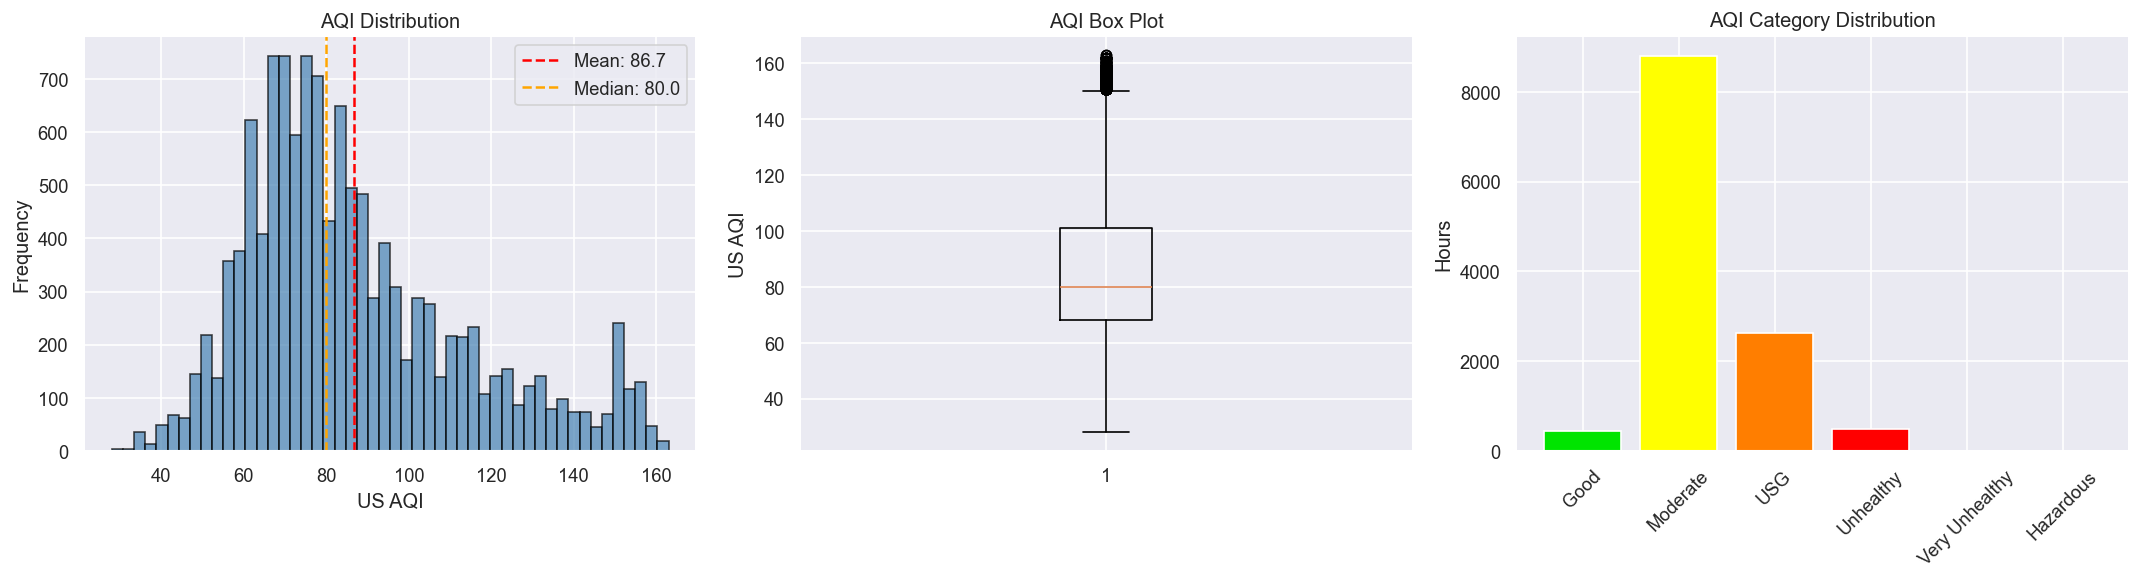


AQI Category Breakdown:
  Good                :   445 (3.6%)
  Moderate            :  8800 (71.2%)
  USG                 :  2626 (21.2%)
  Unhealthy           :   489 (4.0%)
  Very Unhealthy      :     0 (0.0%)
  Hazardous           :     0 (0.0%)


In [10]:
aqi = df['aqi'].dropna()
fig, axes = plt.subplots(1, 3, figsize=(18, 5))

# Histogram
axes[0].hist(aqi, bins=50, color='steelblue', edgecolor='black', alpha=0.7)
axes[0].axvline(aqi.mean(), color='red', linestyle='--', label=f'Mean: {aqi.mean():.1f}')
axes[0].axvline(aqi.median(), color='orange', linestyle='--', label=f'Median: {aqi.median():.1f}')
axes[0].set_xlabel('US AQI')
axes[0].set_ylabel('Frequency')
axes[0].set_title('AQI Distribution')
axes[0].legend()

# Box plot
axes[1].boxplot(aqi, vert=True)
axes[1].set_ylabel('US AQI')
axes[1].set_title('AQI Box Plot')

# AQI categories
cats = pd.cut(aqi, bins=[0, 50, 100, 150, 200, 300, 500], labels=['Good', 'Moderate', 'USG','Unhealthy', 'Very Unhealthy', 'Hazardous'])
cat_counts = cats.value_counts().sort_index()

colors = ['#00e400', '#ffff00', '#ff7e00','#ff0000', '#8f3f97', '#7e0023']

axes[2].bar(cat_counts.index, cat_counts.values, color=colors[:len(cat_counts)])

axes[2].set_ylabel('Hours')
axes[2].set_title('AQI Category Distribution')
axes[2].tick_params(axis='x', rotation=45)

plt.tight_layout()
plt.show()

print('\nAQI Category Breakdown:')
for cat, count in cat_counts.items():
    print(f'  {cat:20s}: {count:5d} ({count/len(aqi)*100:.1f}%)')

### Summary of Graphs
- Histogram: Shows how the AQI values are distributed across different hours (frequency). Divides the data into equal distributions based on AQI values, here difference = 20.
   - Example: Bar is high/at peak in the range of 60-75 showing most records have values between 60-75 in overall dataset.

- Box Plot: Shows data spread, center, variability, outliers and distribution shape. Here it divided the data into lower whisker, box (center part), median line, upper whisker and outlier dots.
   - Example: Lower whisker = ~28 (minimum AQI - clean monsoon air), Bottom of box = ~68 (means 25% of AQI values are below 68), Median = ~80 showing center of data (50-50) distribution.
   -          Top of Box = ~101 (means 75% of AQI values are below 101), Upper whisker = ~150 (showing maximum non-outlier AQI observed)
   -          Black dots above whisker = outlier pollution spike events. Retained intentionally as these are real events (dust storms, temperature inversions) — not data errors.

- AQI Category Distribution (Bar chart): Classifies AQI values into different categories and shows how many AQI records belong to each category. Shows the distribution of AQI categories.
   - Example: Good = ~445 hours, Moderate = ~8800 hours, USG = ~2626 hours, Unhealthy = ~489 hours
   - X-axis: shows the overall AQI categories, Y-axis shows the no. of hours falling into each category.
   - Interpretation: Good AQI = ~445 (3.6%) meaning more clean-air hours now visible, monsoon months (Jul-Sep) bring rainfall that washes pollutants out. Moderate AQI = ~8800 (71.2%) (AQI range = 51-100) meaning most of the time air quality was moderate.

## 6. Outlier Detection — IQR Method

Outliers can heavily skew model training.  
We identify them now so we can decide whether to cap, remove, or keep them.

In [11]:
cols = ["no2","pm10","pm2_5","co","so2","o3","temperature","humidity","wind_speed","pressure","aqi"]

numeric_df = df[cols]

Q1 = numeric_df.quantile(0.25)
Q3 = numeric_df.quantile(0.75)
IQR = Q3 - Q1

lower = Q1 - 1.5 * IQR
upper = Q3 + 1.5 * IQR

outlier_mask = (numeric_df < lower) | (numeric_df > upper)

outlier_summary = pd.DataFrame({
    "outlier_count": outlier_mask.sum(),
    "outlier_pct": (outlier_mask.sum() / len(numeric_df) * 100).round(2),
    "lower_fence": lower.round(2),
    "upper_fence": upper.round(2)
}).sort_values("outlier_pct", ascending=False)

print(outlier_summary)

             outlier_count  outlier_pct  lower_fence  upper_fence
no2                    904         7.31        -9.05        23.35
co                     669         5.41      -394.50      1329.50
pm2_5                  582         4.71        -7.65        59.95
pm10                   574         4.64       -17.80       115.00
aqi                    489         3.96        18.50       150.50
so2                    300         2.43        -1.30        14.70
temperature              2         0.02         7.35        46.95
wind_speed               2         0.02        -5.65        28.35
o3                       0         0.00       -27.50       192.50
humidity                 0         0.00       -22.50       125.50
pressure                 0         0.00       981.70      1028.90


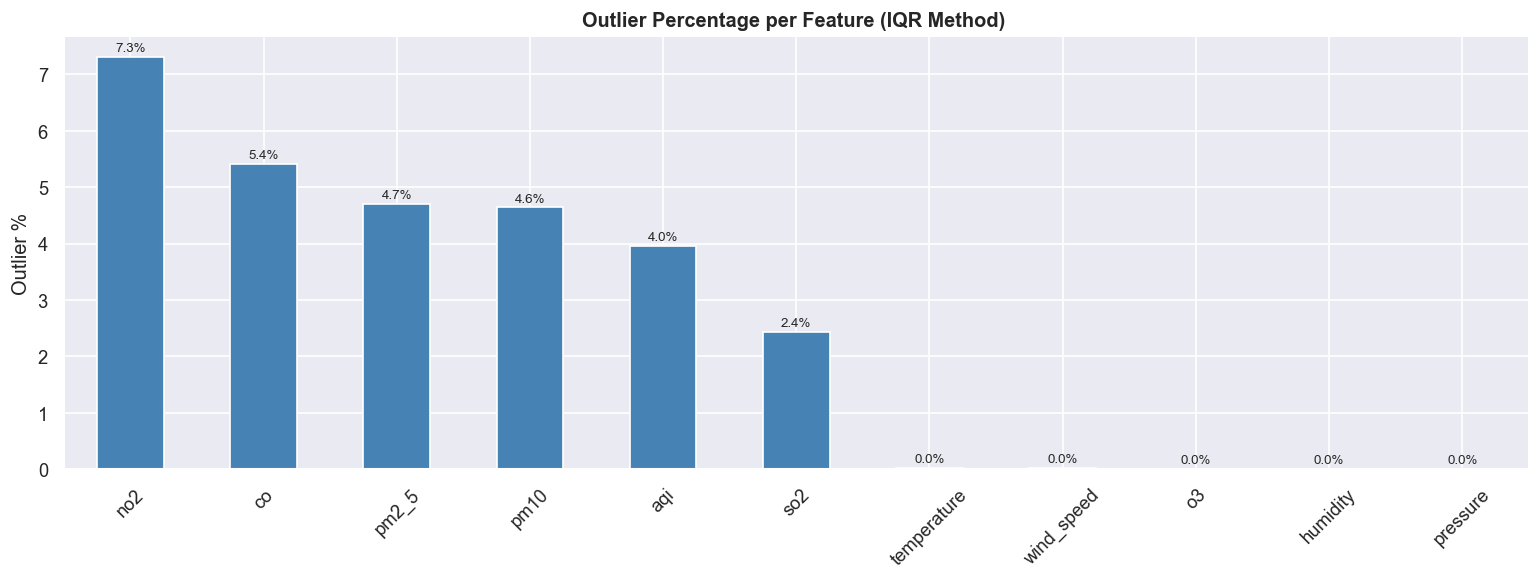

Outliers were analyzed using the IQR method across all numerical features.
Since the dataset represents real-world AQI and weather measurements, extreme values are considered meaningful pollution events rather than data errors.


In [12]:
fig, ax = plt.subplots(figsize=(13, 5))
outlier_summary["outlier_pct"].plot( 
    kind="bar", ax=ax, color="steelblue", edgecolor="white"
)

ax.set_title(f"Outlier Percentage per Feature (IQR Method) ", fontweight="bold")
ax.set_ylabel("Outlier %")
ax.set_xlabel("")
ax.tick_params(axis="x", rotation=45)
for i, v in enumerate(outlier_summary["outlier_pct"]):
    ax.text(i, v + 0.1, f"{v:.1f}%", ha="center", fontsize=8)
plt.tight_layout()
plt.show()

print("Outliers were analyzed using the IQR method across all numerical features.")
print("""Since the dataset represents real-world AQI and weather measurements, extreme values are considered meaningful pollution events rather than data errors.""")

## 7. Time Series Analysis

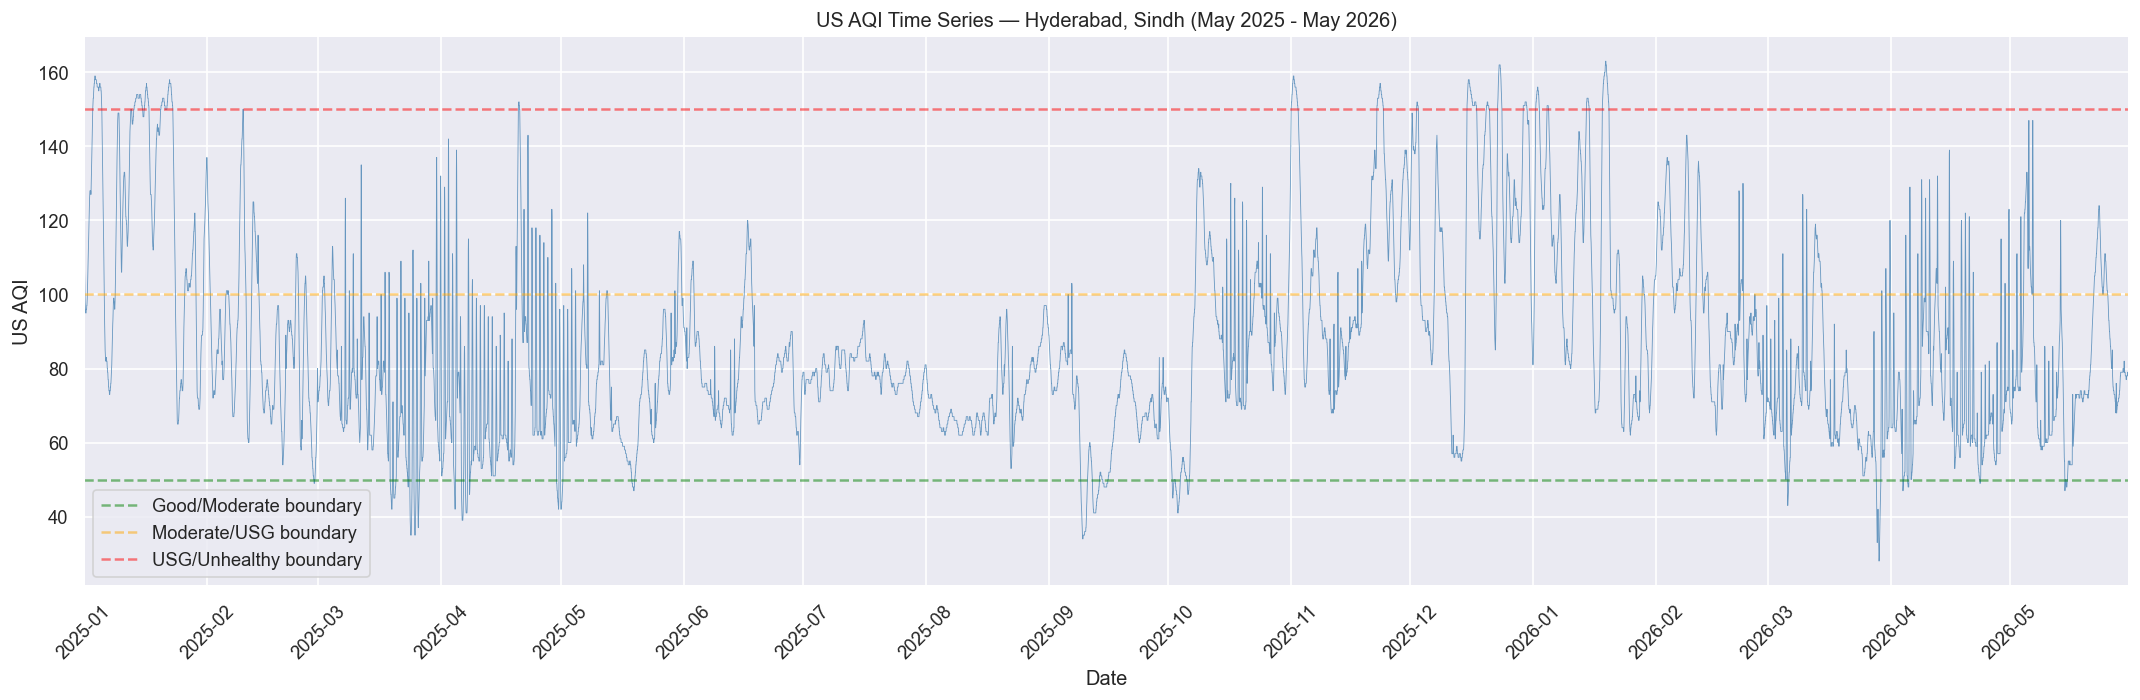

In [13]:
import matplotlib.dates as mdates

fig, ax = plt.subplots(figsize=(18, 6))
ax.plot(df.index, df['aqi'], linewidth=0.5, alpha=0.8, color='steelblue')
ax.axhline(50, color='green', linestyle='--', alpha=0.5, label='Good/Moderate boundary')
ax.axhline(100, color='orange', linestyle='--', alpha=0.5, label='Moderate/USG boundary')
ax.axhline(150, color='red', linestyle='--', alpha=0.5, label='USG/Unhealthy boundary')

ax.set_xlim(df.index.min(), df.index.max())
ax.xaxis.set_major_locator(mdates.MonthLocator())
ax.xaxis.set_major_formatter(mdates.DateFormatter('%Y-%m'))
plt.xticks(rotation=45)

ax.set_xlabel('Date')
ax.set_ylabel('US AQI')
ax.set_title('US AQI Time Series — Hyderabad, Sindh (May 2025 - May 2026)')
ax.legend()
plt.tight_layout()
plt.show()

### Interpretation
- Three thresholds added in graph: (Green, Orange, Red)
- (Green line: AQI = 50 This separates: Good Air Quality & Moderate Air Quality meaning Below 50 = clean air, above 50 = moderate pollution).
- (Orange line: AQI = 100 This separates Moderate & Unhealthy for Sensitive Groups (USG) meaning Above 100 = risky for children, elderly, asthma patients).
- (Red line: AQI = 150 This separates USG & Unhealthy meaning above 150 dangerous pollution level).
- Conclusion: AQI values remains mostly between 50 - 100 by looking at the graph which means air quality is mostly moderate and sometimes unhealthy for sensitive groups

## 8. Precipitation vs AQI (Rainy hours Only)

Correlation: 0.08


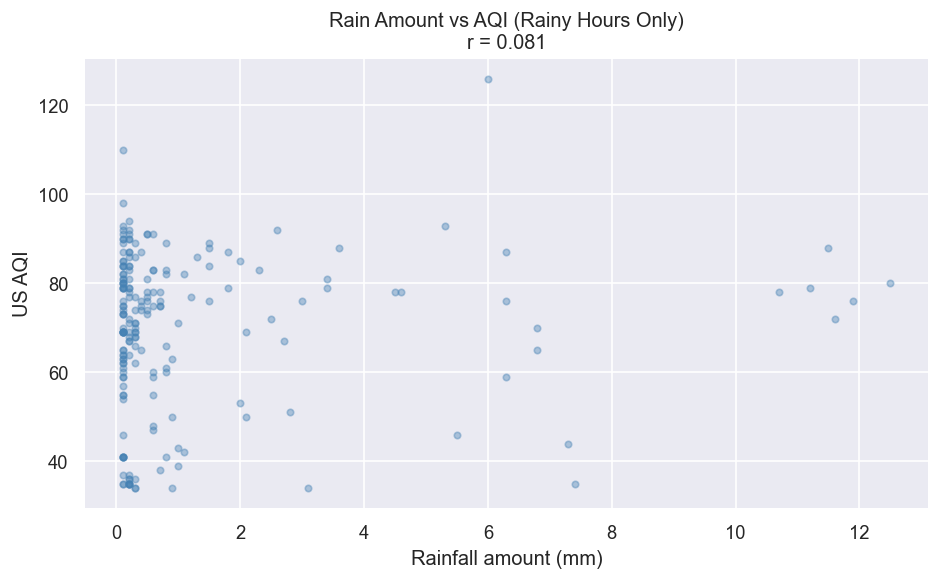

In [14]:
# Rain vs AQI Scatter Plot (With rainy hours only)

rain_df = df[['rain', 'aqi']].dropna().copy()

# keep only rainy hours
rh = rain_df[rain_df['rain'] > 0]

plt.figure(figsize=(8,5))

plt.scatter(rh['rain'], rh['aqi'], alpha=0.4, color='steelblue', s=15)

corr_rain = rh['rain'].corr(rh['aqi'])

plt.title(f'Rain Amount vs AQI (Rainy Hours Only)\nr = {corr_rain:.3f}')
plt.xlabel('Rainfall amount (mm)')
plt.ylabel('US AQI')
print(f"Correlation: {corr_rain:.2f}")
plt.tight_layout()
plt.show()

## 9. Hourly and Day of Week Patterns

Peak AQI hour: 19:00 (AQI=95.1)
Lowest AQI hour: 10:00 (AQI=84.5)
Hourly Variation: 10.6 AQI

Weekday avg AQI (Monday to Friday): 86.4
Weekend avg AQI (Saturday + Sunday): 87.6
Highest AQI day is Sun: 89.7
Lowest AQI day is Fri : 83.6


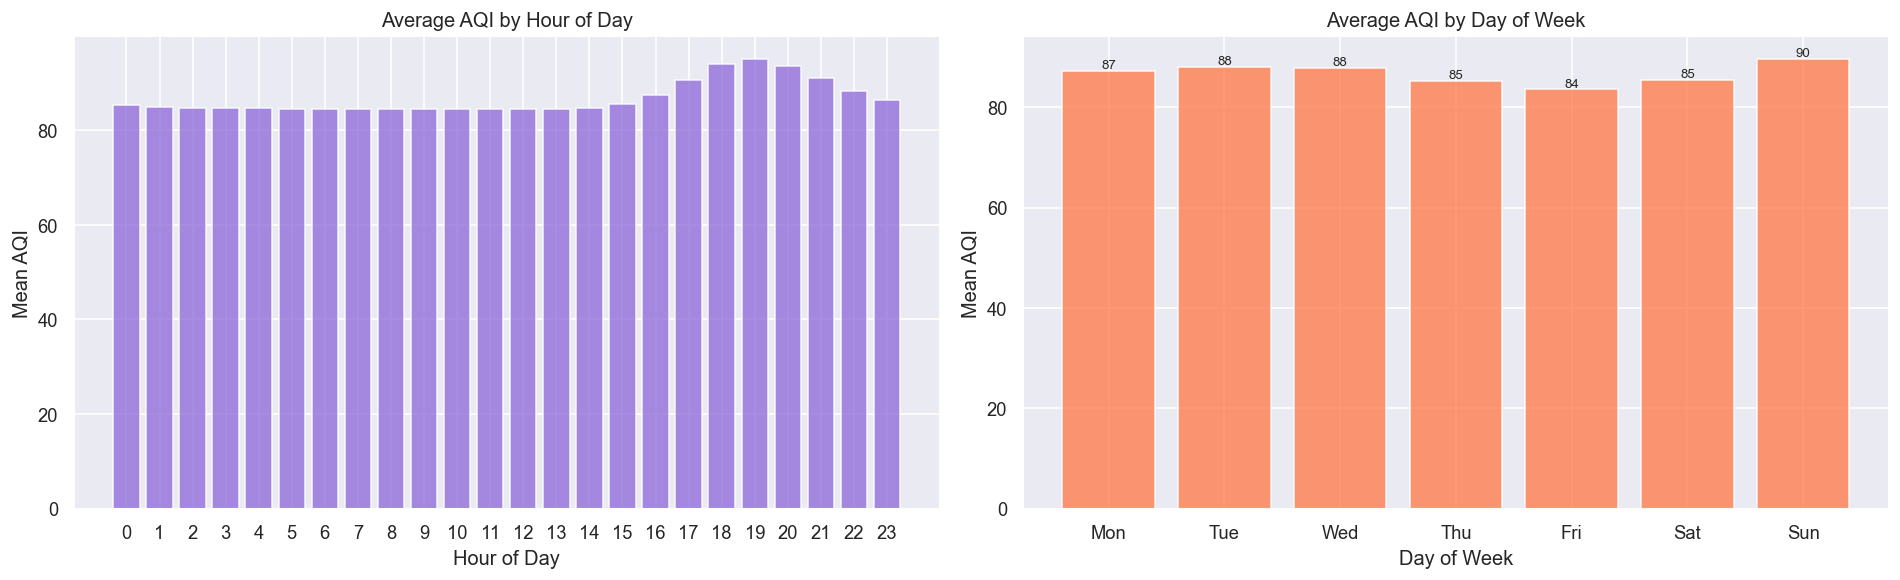

In [15]:
fig, axes = plt.subplots(1, 2, figsize=(16, 5))

# Hourly pattern
hourly = df.groupby(df.index.hour)['aqi'].mean()

axes[0].bar(hourly.index, hourly.values, color='mediumpurple', alpha=0.8)
axes[0].set_xlabel('Hour of Day')
axes[0].set_ylabel('Mean AQI')
axes[0].set_title('Average AQI by Hour of Day')
axes[0].set_xticks(range(0, 24))

peak_hour = hourly.idxmax()
low_hour = hourly.idxmin()

print(f'Peak AQI hour: {peak_hour}:00 (AQI={hourly[peak_hour]:.1f})')
print(f'Lowest AQI hour: {low_hour}:00 (AQI={hourly[low_hour]:.1f})')
print(f'Hourly Variation: {hourly.max() - hourly.min():.1f} AQI')

# Day of week pattern
dow_avg = df.groupby(df.index.dayofweek)['aqi'].mean()

day_names = ['Mon', 'Tue', 'Wed', 'Thu', 'Fri', 'Sat', 'Sun']

axes[1].bar(day_names, dow_avg.values, color='coral', alpha=0.8)
axes[1].set_xlabel('Day of Week')
axes[1].set_ylabel('Mean AQI')
axes[1].set_title('Average AQI by Day of Week')

# Day with highest and lowest average AQI
max_day_idx = dow_avg.idxmax()
min_day_idx = dow_avg.idxmin()

for i, v in enumerate(dow_avg.values):
    axes[1].text(i, v + 0.5, f'{v:.0f}', ha='center', fontsize=8)

print(f'\nWeekday avg AQI (Monday to Friday): {dow_avg[:5].mean():.1f}')
print(f'Weekend avg AQI (Saturday + Sunday): {dow_avg[5:].mean():.1f}')
print(f'Highest AQI day is {day_names[max_day_idx]}: {dow_avg[max_day_idx]:.1f}')
print(f'Lowest AQI day is {day_names[min_day_idx]} : {dow_avg[min_day_idx]:.1f}')


plt.tight_layout()
plt.show()

### Interpretation
##### 1. Average AQI by Hour of Day: 
- Shows which hours AQI is usually higher or lower
- Groups all AQI readings by hour like all 7-AM values are added up together and divided by 'n' total values to compute average of particular hour.
- Example: May-1: 6 AM AQI = 72 + May-2: 6 AM AQI = 72 ==> Total = 72+72/2 = 72. (Important: By looking at graph AQI remains between 85 - 93 throughout the day).
- AQI slightly increases in evening like from 16:00 (4 PM) - 20:00 (8 PM) due to evening traffic and human activity while lowest AQI appears at 10:00 (noon) due to solar heating and wind dispersal.
- Peak AQI hour: 19:00 (AQI=95.1), Lowest AQI hour: 10:00 (AQI=84.5), Hourly Variation: 10.6 AQI

##### 2. Average AQI by Day of Week:
- Shows which weekdays are more polluted
- Groups AQI by days like Monday May-11 + Monday May-18... AQI values are added up together and divided by total no. of Mondays to compute average AQI of particular day.
- Example say: Monday May-11: AQI = 90, Monday May-18: AQI = 95 ==> Total = 90+95/2 = 92.5. (Important: By looking at graph Sunday AQI appears slightly high at 90).
>   Average AQI for weekdays (Monday to Friday) = 86.4  
>   Average AQI for Weekend (Saturday & Sunday) = 87.6 
Meaning weekends are more pollutants as compared to weekday's due to huge traffic and human activities. 

## 10. Autocorrelation Analysis
#### How well does past AQI predict future AQI?

  Lag   1h: r = 0.992
  Lag   3h: r = 0.945
  Lag   6h: r = 0.875
  Lag  12h: r = 0.800
  Lag  24h: r = 0.743
  Lag  48h: r = 0.570
  Lag  72h: r = 0.508


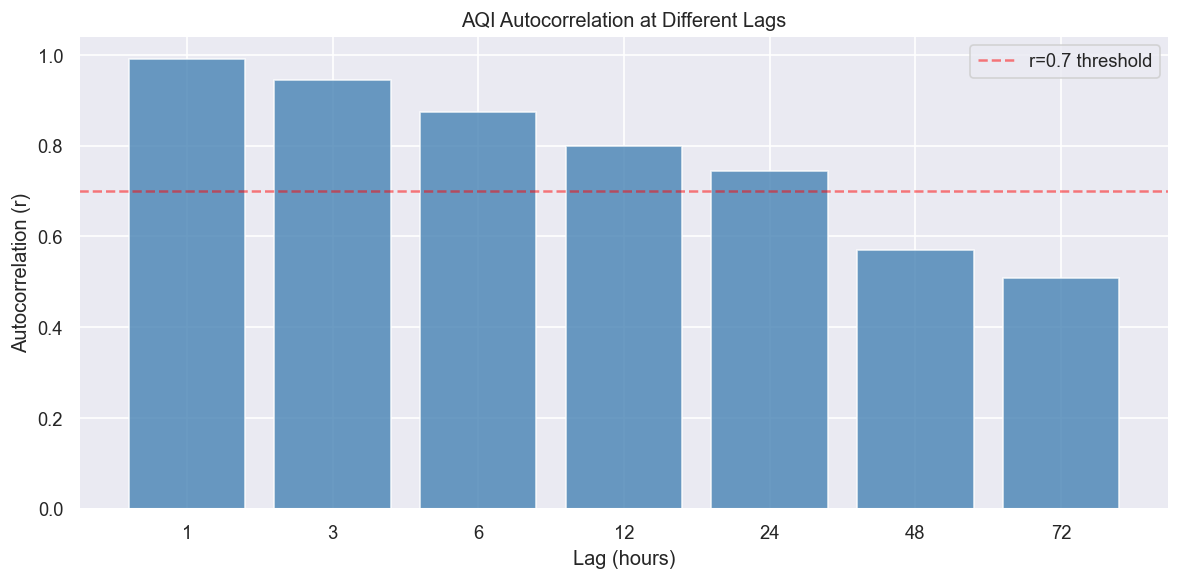


Key finding: AQI is highly persistent (r=0.74 at 24h lag).
This means lag features will be our strongest predictors.
Lag Feature Decisions:
  Lag   1h : r = 0.992  →  INCLUDE
  Lag   3h : r = 0.945  →  INCLUDE
  Lag   6h : r = 0.875  →  INCLUDE
  Lag  12h : r = 0.800  →  INCLUDE
  Lag  24h : r = 0.743  →  INCLUDE
  Lag  48h : r = 0.570  →  optional
  Lag  72h : r = 0.508  →  optional


In [16]:
lags = [1, 3, 6, 12, 24, 48, 72]
autocorrs = []

aqi = df['aqi'].dropna()
for lag in lags:
    corr = aqi.corr(aqi.shift(lag))
    autocorrs.append(corr)
    print(f'  Lag {lag:3d}h: r = {corr:.3f}')

fig, ax = plt.subplots(figsize=(10, 5))
ax.bar([str(l) for l in lags], autocorrs, color='steelblue', alpha=0.8)
ax.set_xlabel('Lag (hours)')
ax.set_ylabel('Autocorrelation (r)')
ax.set_title('AQI Autocorrelation at Different Lags')
ax.axhline(0.7, color='red', linestyle='--', alpha=0.5, label='r=0.7 threshold')
ax.legend()
plt.tight_layout()
plt.show()

print('\nKey finding: AQI is highly persistent (r=0.74 at 24h lag).')
print('This means lag features will be our strongest predictors.')
#Feature Engineering Decision─
print("Lag Feature Decisions:")
for lag, corr in zip(lags, autocorrs):
    decision = "INCLUDE" if corr >= 0.7 else "optional" if corr >= 0.5 else "skip"
    print(f"  Lag {lag:3d}h : r = {corr:.3f}  →  {decision}")

## 11. Weather and Pollutants VS AQI Correlations

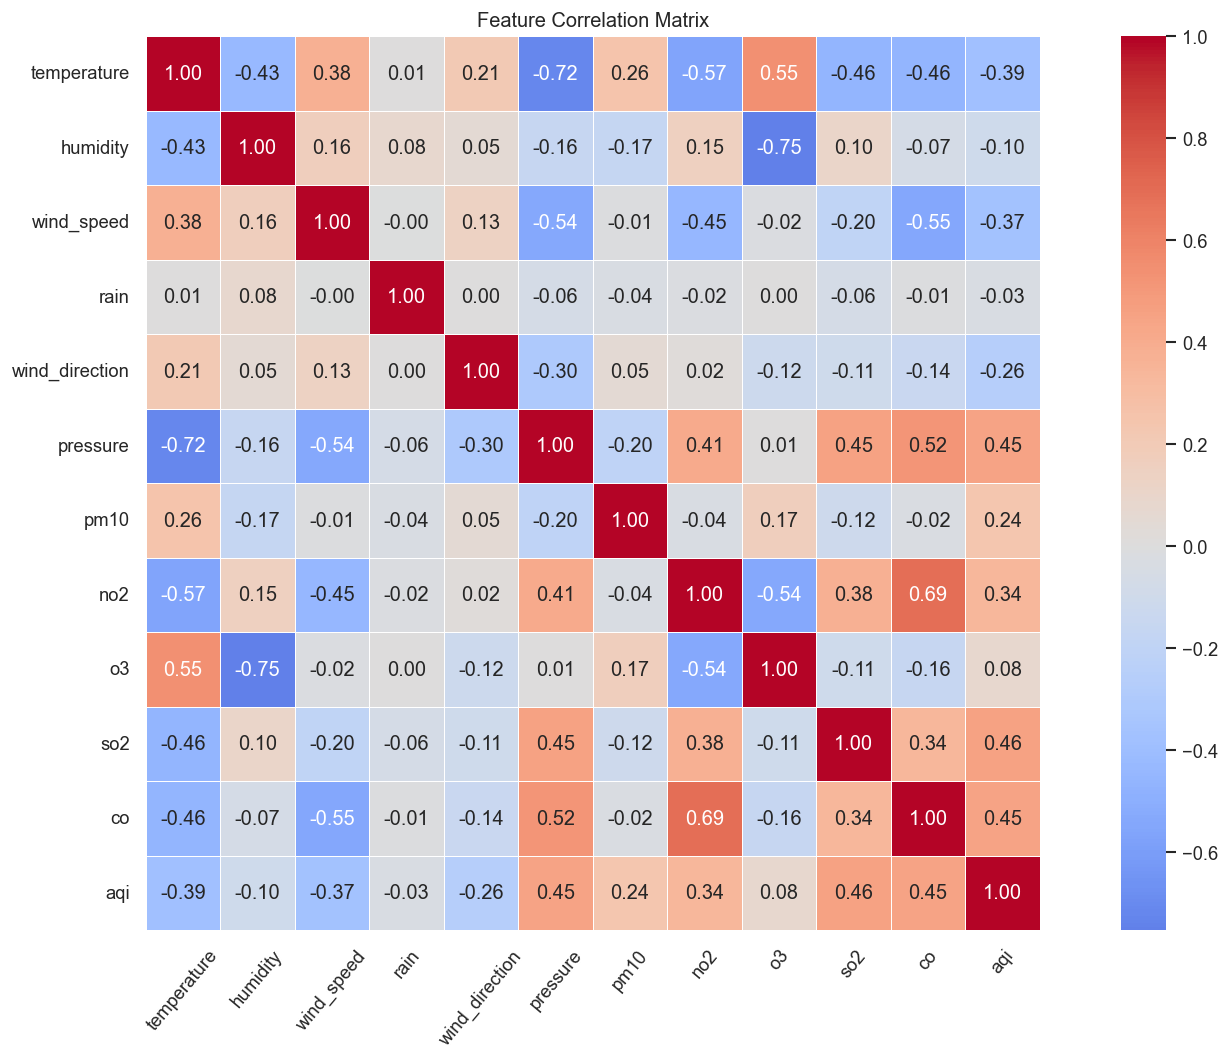


Correlations with US AQI:
  so2            : r = +0.458  (Higher value → HIGHER AQI)
  pressure       : r = +0.450  (Higher value → HIGHER AQI)
  co             : r = +0.448  (Higher value → HIGHER AQI)
  temperature    : r = -0.386  (Higher value → LOWER AQI)
  wind_speed     : r = -0.369  (Higher value → LOWER AQI)
  no2            : r = +0.340  (Higher value → HIGHER AQI)
  wind_direction : r = -0.255  (Higher value → LOWER AQI)
  pm10           : r = +0.239  (Higher value → HIGHER AQI)
  humidity       : r = -0.103  (Higher value → LOWER AQI)
  o3             : r = +0.081  (Higher value → HIGHER AQI)
  rain           : r = -0.030  (Higher value → LOWER AQI)


In [17]:
weather_cols = ['temperature', 'humidity', 'wind_speed', 'rain', 'wind_direction', 'pressure']
pollutant_cols = ['pm10', 'no2', 'o3', 'so2', 'co']
all_cols = weather_cols + pollutant_cols + ['aqi']

corr_matrix = df[all_cols].corr()

fig, ax = plt.subplots(figsize=(14, 9))
sns.heatmap(corr_matrix, annot=True, fmt='.2f', cmap='coolwarm', center=0, ax=ax,
            square=True, linewidths=0.5)

ax.set_xticklabels(ax.get_xticklabels(), rotation=50, ha='center')

ax.set_title('Feature Correlation Matrix')
plt.tight_layout()
plt.show()

print('\nCorrelations with US AQI:')
aqi_corr = corr_matrix['aqi'].drop('aqi').sort_values(key=abs, ascending=False)

for col, corr in aqi_corr.items():
    direction = 'Higher value → LOWER AQI' if corr < 0 else 'Higher value → HIGHER AQI'
    print(f'  {col:15s}: r = {corr:+.3f}  ({direction})')

## 12. Seasonal AQI Trends
- The seasonal AQI analysis was performed using historical data collected from 01-Jan-2025 to 30-May-2026. 

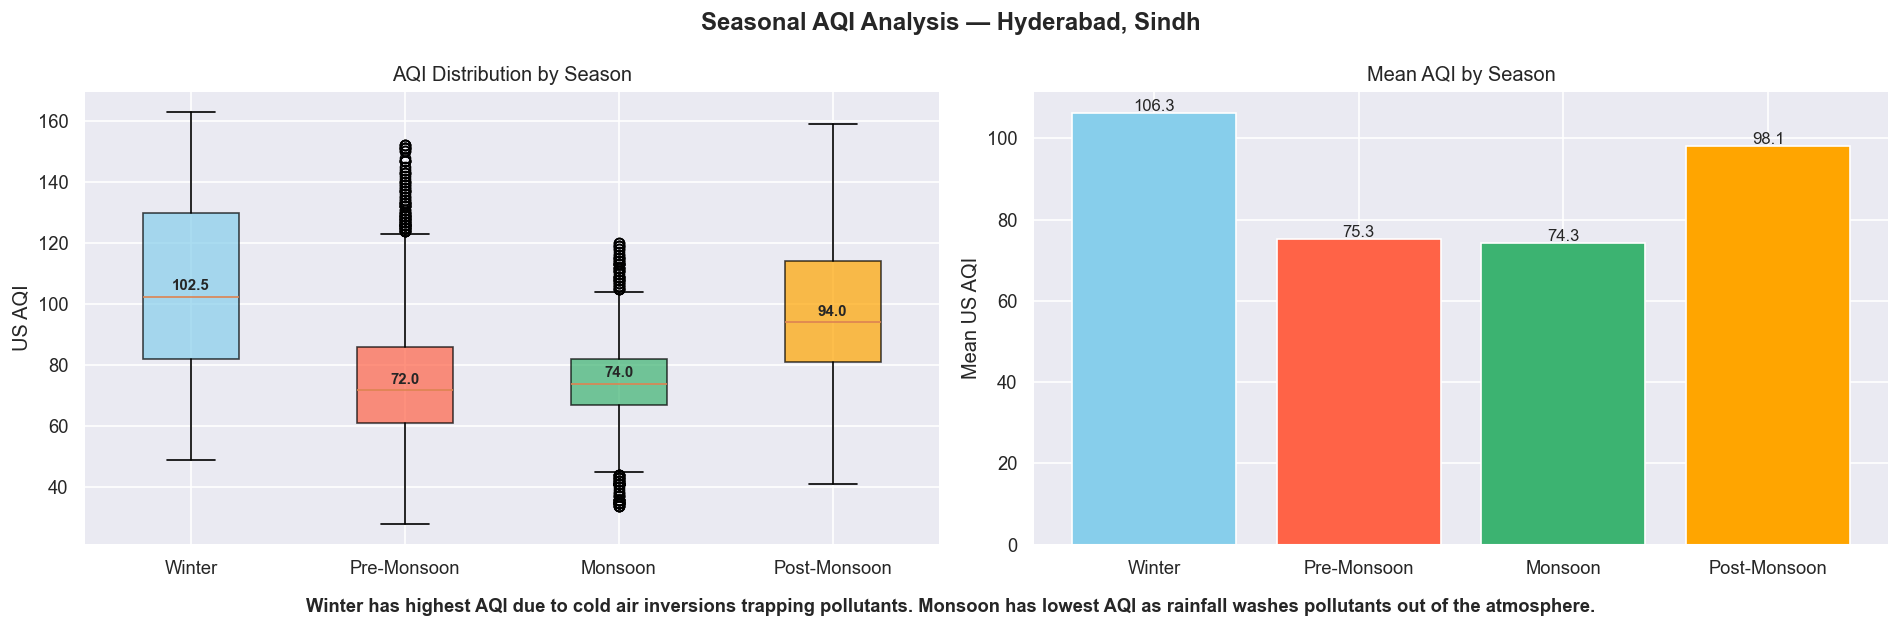

Seasonal AQI Summary:
Season              Mean   Median      Std      Min      Max
------------------------------------------------------------
Winter             106.3    102.5     29.3     49.0    163.0
Pre-Monsoon         75.3     72.0     19.7     28.0    152.0
Monsoon             74.3     74.0     12.1     34.0    120.0
Post-Monsoon        98.1     94.0     26.5     41.0    159.0


In [18]:
def get_season(month):
    if month in [12, 1, 2]:
        return "Winter"
    elif month in [3, 4, 5]:
        return "Pre-Monsoon"
    elif month in [6, 7, 8, 9]:
        return "Monsoon"
    else: # 10, 11
        return "Post-Monsoon"


df_season = df[['aqi']].dropna().copy()
df_season.index = pd.to_datetime(df_season.index)
df_season["season"] = df_season.index.month.map(get_season)

season_order  = ["Winter", "Pre-Monsoon", "Monsoon", "Post-Monsoon"]
season_colors = ["skyblue", "tomato", "mediumseagreen", "orange"]
available_seasons = [s for s in season_order if s in df_season["season"].values]

fig, axes = plt.subplots(1, 2, figsize=(16, 5))

# Box plot by season
season_data = [
    df_season[df_season["season"] == s]['aqi'].dropna().values
    for s in available_seasons
]

bp = axes[0].boxplot(season_data, patch_artist=True, labels=available_seasons)

for patch, color in zip(bp["boxes"], season_colors[:len(available_seasons)]):
    patch.set_facecolor(color)
    patch.set_alpha(0.7)

axes[0].set_title("AQI Distribution by Season")
axes[0].set_ylabel("US AQI")

# Median labels on box plot
for i, s in enumerate(available_seasons, 1):
    median_val = df_season[df_season["season"] == s]["aqi"].median()
    axes[0].text(i, median_val + 2, f"{median_val:.1f}",
                 ha="center", fontsize=9, fontweight="bold")

# Mean AQI bar chart by season
season_means = df_season.groupby("season")['aqi'].mean().reindex(available_seasons)

axes[1].bar(season_means.index, season_means.values,
            color=season_colors[:len(season_means)], edgecolor="white")
axes[1].set_title("Mean AQI by Season")
axes[1].set_ylabel("Mean US AQI")

for i, v in enumerate(season_means.values):
    axes[1].text(i, v + 0.5, f"{v:.1f}", ha="center", fontsize=10)

plt.suptitle("Seasonal AQI Analysis — Hyderabad, Sindh", fontweight="bold")

plt.figtext(
    0.5, -0.02,
    "Winter has highest AQI due to cold air inversions trapping pollutants. "
    "Monsoon has lowest AQI as rainfall washes pollutants out of the atmosphere.",
    ha="center", fontsize=11, fontweight="bold"
)

plt.tight_layout()
plt.show()

# Print seasonal summary
print("Seasonal AQI Summary:")
print(f"{'Season':<15} {'Mean':>8} {'Median':>8} {'Std':>8} {'Min':>8} {'Max':>8}")
print("-" * 60)
for s in available_seasons:
    data = df_season[df_season["season"] == s]["aqi"]
    print(f"{s:<15} {data.mean():>8.1f} {data.median():>8.1f} "
          f"{data.std():>8.1f} {data.min():>8.1f} {data.max():>8.1f}")

## 13. AQI by Temperature and Wind
### The two strongest weather predictors from the correlation analysis.

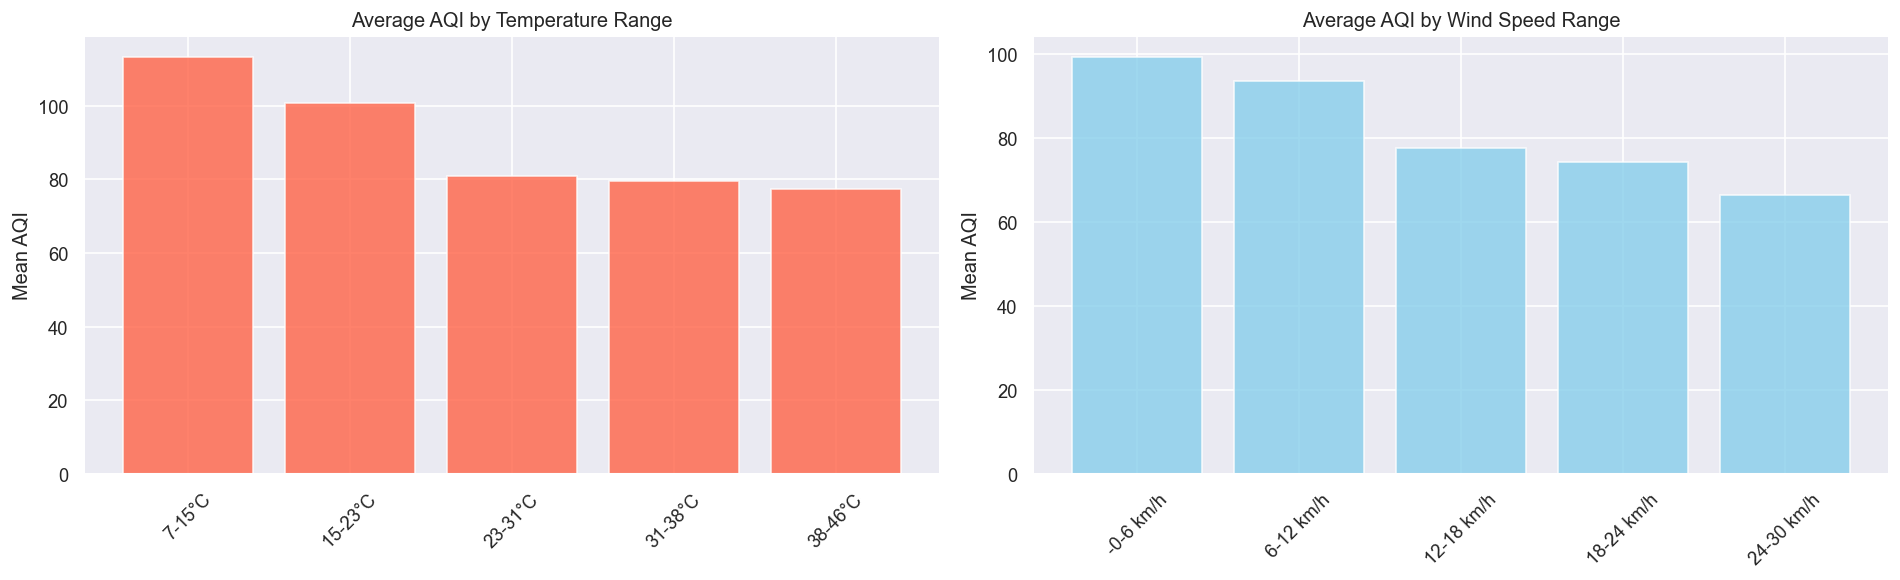


Key finding: Cold + calm = Worst AQI (Higher).
Hot + windy = Best AQI (Lower).


In [19]:
temp_df = df[['temperature', 'wind_speed', 'aqi']].dropna().copy()

fig, axes = plt.subplots(1, 2, figsize=(16, 5))

# Temperature bins
temp_df['temp_bin'] = pd.cut(temp_df['temperature'], bins=5)

temp_aqi = temp_df.groupby('temp_bin', observed= False)['aqi'].mean()

axes[0].bar(range(len(temp_aqi)), temp_aqi.values, color='tomato', alpha=0.8)

axes[0].set_xticks(range(len(temp_aqi)))

axes[0].set_xticklabels([f'{x.left:.0f}-{x.right:.0f}°C' for x in temp_aqi.index], rotation=45)

axes[0].set_ylabel('Mean AQI')
axes[0].set_title('Average AQI by Temperature Range')

# Wind speed bins
temp_df['wind_bin'] = pd.cut(temp_df['wind_speed'], bins=5)

wind_aqi = temp_df.groupby('wind_bin', observed=False)['aqi'].mean()

axes[1].bar(range(len(wind_aqi)), wind_aqi.values, color='skyblue', alpha=0.8)

axes[1].set_xticks(range(len(wind_aqi)))

axes[1].set_xticklabels([f'{x.left:.0f}-{x.right:.0f} km/h' for x in wind_aqi.index], rotation=45)

axes[1].set_ylabel('Mean AQI')
axes[1].set_title('Average AQI by Wind Speed Range')


plt.tight_layout()
plt.show()


print('\nKey finding: Cold + calm = Worst AQI (Higher).')
print('Hot + windy = Best AQI (Lower).')

## 14. PM2.5 and AQI Relationship
##### US AQI in Hyderabad is strongly influenced by PM2.5 concentration levels. Higher PM2.5 values generally correspond to higher AQI.

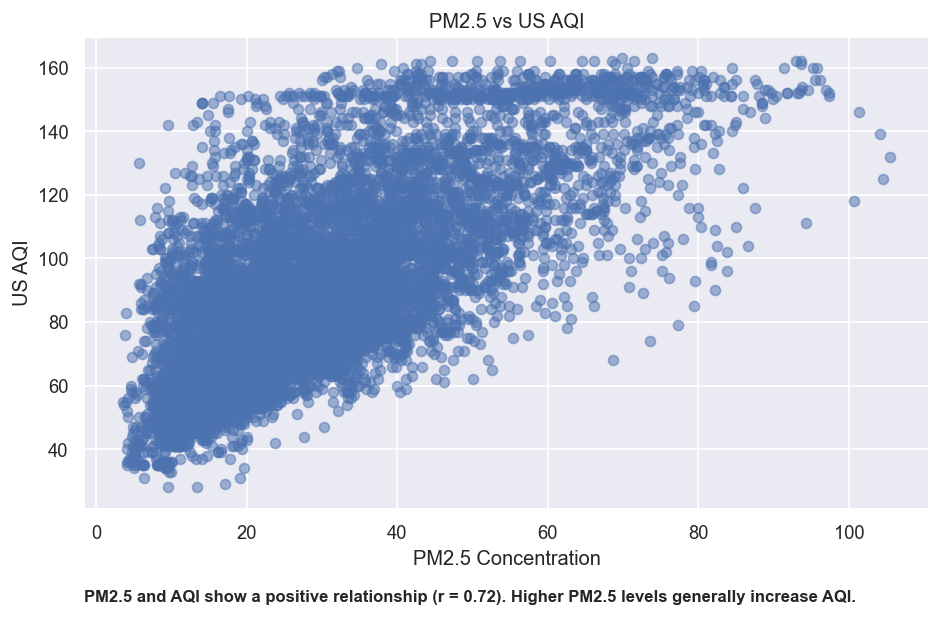

Correlation between PM2.5 and AQI: r = 0.720
This will be our strong AQI predictor feature.


In [20]:
# PM2.5 vs AQI Relationship

pm25_df = df[['pm2_5', 'aqi']].dropna().copy()


plt.figure(figsize=(8, 5))

plt.scatter(
    pm25_df['pm2_5'],
    pm25_df['aqi'],
    alpha=0.5
)

plt.xlabel("PM2.5 Concentration")
plt.ylabel("US AQI")

plt.title("PM2.5 vs US AQI")


# Correlation
corr = pm25_df['pm2_5'].corr(pm25_df['aqi'])

plt.figtext(
    0.5, -0.02,
    f"PM2.5 and AQI show a positive relationship (r = {corr:.2f}). Higher PM2.5 levels generally increase AQI.",
    ha="center",
    fontsize=10,
    fontweight="bold"
)

plt.tight_layout()
plt.show()

print(f"Correlation between PM2.5 and AQI: r = {corr:.3f}")
print(f"This will be our strong AQI predictor feature.")

## 15. Feature Engineering Design Decision

Based on EDA findings across **16 months (Jan 2025 – May 2026 · 12,360 rows · 515 days)**,
we designed **60 features across 11 groups** → 3 targets (aqi_24h, aqi_48h, aqi_72h).

| Group | Count | Features | Rationale (16-month data) |
|---|---|---|---|
| Weather | 8 | `temperature`, `humidity`, `wind_speed`, `rain`, `pressure`, `weather_code`, `wind_dir_sin`, `wind_dir_cos` | `wind_speed` r=−0.369, `temperature` r=−0.386, `pressure` r=+0.450. `wind_direction` encoded as sin/cos — circular feature (0°=360°) |
| Pollutants | 6 | `pm2_5`, `so2`, `co`, `no2`, `pm10`, `o3` | `so2` r=+0.458, `co` r=+0.448, `pm2_5` r=+0.720. Current-hour PM2.5 kept — it is the sensor reading at inference time, not the target |
| **Future weather t+24** | 5 | `temp_24h`, `wind_24h`, `pressure_24h`, `humidity_24h`, `pm2_5_24h` | Day-1 horizon context. Fetched from OpenMeteo 4-day forecast at inference time |
| **Future weather t+36** | 5 | `temp_36h`, `wind_36h`, `pressure_36h`, `humidity_36h`, `pm2_5_36h` | Bridge features — midpoint between Day-1 and Day-2 horizons. Closes the Day-2 accuracy gap |
| **Future weather t+48** | 5 | `temp_48h`, `wind_48h`, `pressure_48h`, `humidity_48h`, `pm2_5_48h` | Day-2 forecast horizon context |
| **Future weather t+72** | 5 | `temp_72h`, `wind_72h`, `pressure_72h`, `humidity_72h`, `pm2_5_72h` | Day-3 forecast horizon context |
| **Cyclical time** | 6 | `hour_sin`, `hour_cos`, `month_sin`, `month_cos`, `dow_sin`, `dow_cos` | Sin/cos handles wrap-around — hour 23 and hour 0 are 1h apart, not 23h apart. Critical for monsoon seasonality visible in 16-month data |
| **Time flags** | 5 | `is_night`, `is_morning_rush`, `is_afternoon`, `is_evening_rush`, `is_weekend` | Tree models learn sharp period boundaries better from binary flags. Peak 19:00 (AQI=93.0), Low 12:00 (AQI=85.3). Weekday=86.7 vs Weekend=87.3 |
| **Lag features** | 8 | `aqi_lag_1h`, `aqi_lag_3h`, `aqi_lag_6h`, `aqi_lag_12h`, `aqi_lag_24h`, `aqi_lag_36h`, `aqi_lag_48h`, `aqi_lag_72h` | r=0.992 (1h), r=0.943 (3h), r=0.875 (6h), r=0.800 (12h), r=0.743 (24h), r=0.570 (48h), r=0.508 (72h). lag_36h added as Day-2 bridge anchor |
| **Rolling statistics** | 3 | `aqi_rolling_mean_24h`, `aqi_rolling_std_24h`, `aqi_rolling_mean_6h` | Captures pollution persistence; std flags volatile vs stable episodes |
| **Derived / interaction** | 4 | `aqi_change_rate`, `dispersion_index`, `heat_humidity`, `pressure_change` | Physics-informed: `dispersion_index = wind_speed × temperature` captures atmospheric dispersal; `pressure_change` detects approaching weather fronts |
| **TOTAL** | **60** | | |

---


### Excluded features

- `aqi` — target/output variable, including it as a feature is direct data leakage
- `wind_direction` (raw degrees) | Consumed to produce `wind_dir_sin` / `wind_dir_cos`, then dropped
- Lags beyond 72h | r < 0.5 — adds noise beyond the forecasting horizon


## Key Findings Summary

| # | Finding | Evidence |
|---|---|---|
| 1 | **Dataset is complete and clean**: no missing values, duplicates, or time gaps across entire 365-day period | 12360 records, 0 missing |
| 2 | **AQI is predominantly Moderate**: Hyderabad faces chronic baseline pollution with seasonal variation | Moderate ~71.2%, USG ~21.2%, Good ~3.6%, Unhealthy ~4.0% |
| 3 | **AQI shows strong temporal dependence**: with very high short-term autocorrelation | r=0.993 (1h lag), r=0.750 (24h lag) — 24h correlation improved with full annual cycle |
| 4 | **Atmospheric pressure** shows a moderate positive relationship with AQI | r=+0.450, indicating pollutant accumulation under high-pressure stable conditions |
| 5 | **Ozone, rainfall, and humidity show negligible linear correlation** | r=+0.081 (o3), r=−0.030 (rain), r=−0.103 (humidity) — confirmed across full annual cycle including monsoon |
| 6 | **Cold + calm = worst AQI, Hot + windy = best AQI**: temperature and wind are the strongest natural dispersers | r=−0.386 (temp), r=−0.369 (wind_speed) |
| 7 | **Combustion emissions are the primary pollution source**: pressure, CO and SO₂ are strongest AQI predictors | r=+0.450 (pressure), r=+0.448 (CO), r=+0.458 (SO₂) |
| 8 | **Clear daily AQI cycle**: peaks at 19:00 7 PM from evening traffic, lowest at 10:00 from solar heating and wind | Peak 19:00 (AQI=95.1), Low 10:00 (AQI=84.5), Variation=10.6 |
| 9 | **Weekday vs weekend AQI nearly identical**  traffic-driven pattern diluted by monsoon months | Weekday 86.4 vs Weekend 87.6 (difference = 1.2 points only) |
| 10 | **Strong seasonal variation across 4 seasons** — winter AQI is 32 points higher than monsoon | Winter mean=106.3, Pre-Monsoon=75.3, Monsoon=74.3, Post-Monsoon=98.1 |
| 11 | **Data is continuous** | No time gaps in the 365-day dataset |

## 16. Feature Importance — SHAP Analysis

SHAP (SHapley Additive exPlanations) validates our feature engineering decisions
by showing what the trained model *actually* learned 

In [21]:
import warnings
warnings.filterwarnings("ignore")
 
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import shap
  
from src.features.feature_engineering import get_features, TARGET_COLUMNS
from src.database.database_connection import get_db_client
from src.database.model_registry import load_model
from config.settings import MONGO_COLLECTION
 
sns.set_theme(style="whitegrid", palette="Blues_d")
plt.rcParams.update({
    "font.family":      "DejaVu Sans",
    "axes.titleweight": "bold",
    "axes.labelweight": "bold",
    "figure.facecolor": "white",
    "axes.facecolor":   "white",
})
 
TOP_N       = 15
SHAP_SAMPLE = 500
RANDOM_SEED = 42
TRAIN_RATIO = 0.80
HORIZONS    = ["24h", "48h", "72h"]
 
print("✅ Imports and style configured.")

✅ Imports and style configured.


In [22]:
# ── Fetch data from MongoDB ───────────────────────────────────
client, db   = get_db_client()
col          = db[MONGO_COLLECTION]
all_features = get_features("24h")

projection = {c: 1 for c in all_features + TARGET_COLUMNS}
projection["timestamp"] = 1
projection["_id"]       = 0

docs = list(col.find({"aqi_24h": {"$ne": None}}, projection))
df   = pd.DataFrame(docs).sort_values("timestamp").reset_index(drop=True)
df[all_features] = df[all_features].ffill().fillna(0)

print(f"✅ Loaded {len(df):,} rows  |  "
      f"{df['timestamp'].iloc[0].date()} → {df['timestamp'].iloc[-1].date()}")

# ── Load best models + compute SHAP ──────────────────────────
shap_data      = {}
HORIZON_LABELS = {}

for horizon in HORIZONS:
    target    = f"aqi_{horizon}"
    feat_cols = get_features(horizon)
    split_idx = int(len(df) * TRAIN_RATIO)

    X_train = df.iloc[:split_idx][feat_cols].values
    X_test  = df.iloc[split_idx:][feat_cols].values
    y_train = df.iloc[:split_idx][target].values

    rng        = np.random.default_rng(RANDOM_SEED)
    sample_idx = rng.choice(len(X_test), size=min(SHAP_SAMPLE, len(X_test)), replace=False)
    X_shap     = X_test[sample_idx]

    bundle     = load_model(db, target)
    model      = bundle["model"]
    scaler     = bundle["scaler"]
    model_name = bundle["model_name"]

    day_num = HORIZONS.index(horizon) + 1
    HORIZON_LABELS[horizon] = f"Day {day_num} ({horizon}) — {model_name}"

    if model_name == "LinearRegression":
        X_train_scaled = scaler.transform(X_train)
        X_shap_scaled  = scaler.transform(X_shap)
        explainer      = shap.LinearExplainer(model, X_train_scaled)
        shap_vals      = explainer.shap_values(X_shap_scaled)
        expected_val   = float(explainer.expected_value)
        X_shap_final   = X_shap_scaled
    else:
        explainer    = shap.TreeExplainer(model)
        shap_vals    = explainer.shap_values(X_shap)
        expected_val = float(explainer.expected_value)
        X_shap_final = X_shap

    shap_data[horizon] = {
        "model":          model,
        "model_name":     model_name,
        "scaler":         scaler,
        "shap_values":    shap_vals,
        "expected_value": expected_val,
        "X_shap":         X_shap_final,
        "X_train":        X_train,
        "X_test":         X_test,
        "feat_cols":      feat_cols,
    }

    print(f"  [{horizon.upper()}] {model_name:<22} | "
          f"Features: {len(feat_cols):<2} | "
          f"E[f(x)]: {expected_val:.1f} | "
          f"SHAP samples: {len(shap_vals)}")

def get_top_features(horizon: str, n: int = TOP_N):
    d = shap_data[horizon]
    mean_abs = np.abs(d["shap_values"]).mean(axis=0)
    feat_df  = pd.DataFrame({"feature": d["feat_cols"], "mean_abs_shap": mean_abs})
    return (
        feat_df
        .sort_values("mean_abs_shap", ascending=False)
        .head(n)
        .reset_index(drop=True)
    )

print("\n✅ Models loaded, SHAP computed.")

✅ Loaded 12,336 rows  |  2025-01-04 → 2026-06-03
  [24H] XGBoost                | Features: 60 | E[f(x)]: 88.7 | SHAP samples: 500
  [48H] XGBoost                | Features: 57 | E[f(x)]: 88.5 | SHAP samples: 500
  [72H] XGBoost                | Features: 55 | E[f(x)]: 88.5 | SHAP samples: 500

✅ Models loaded, SHAP computed.


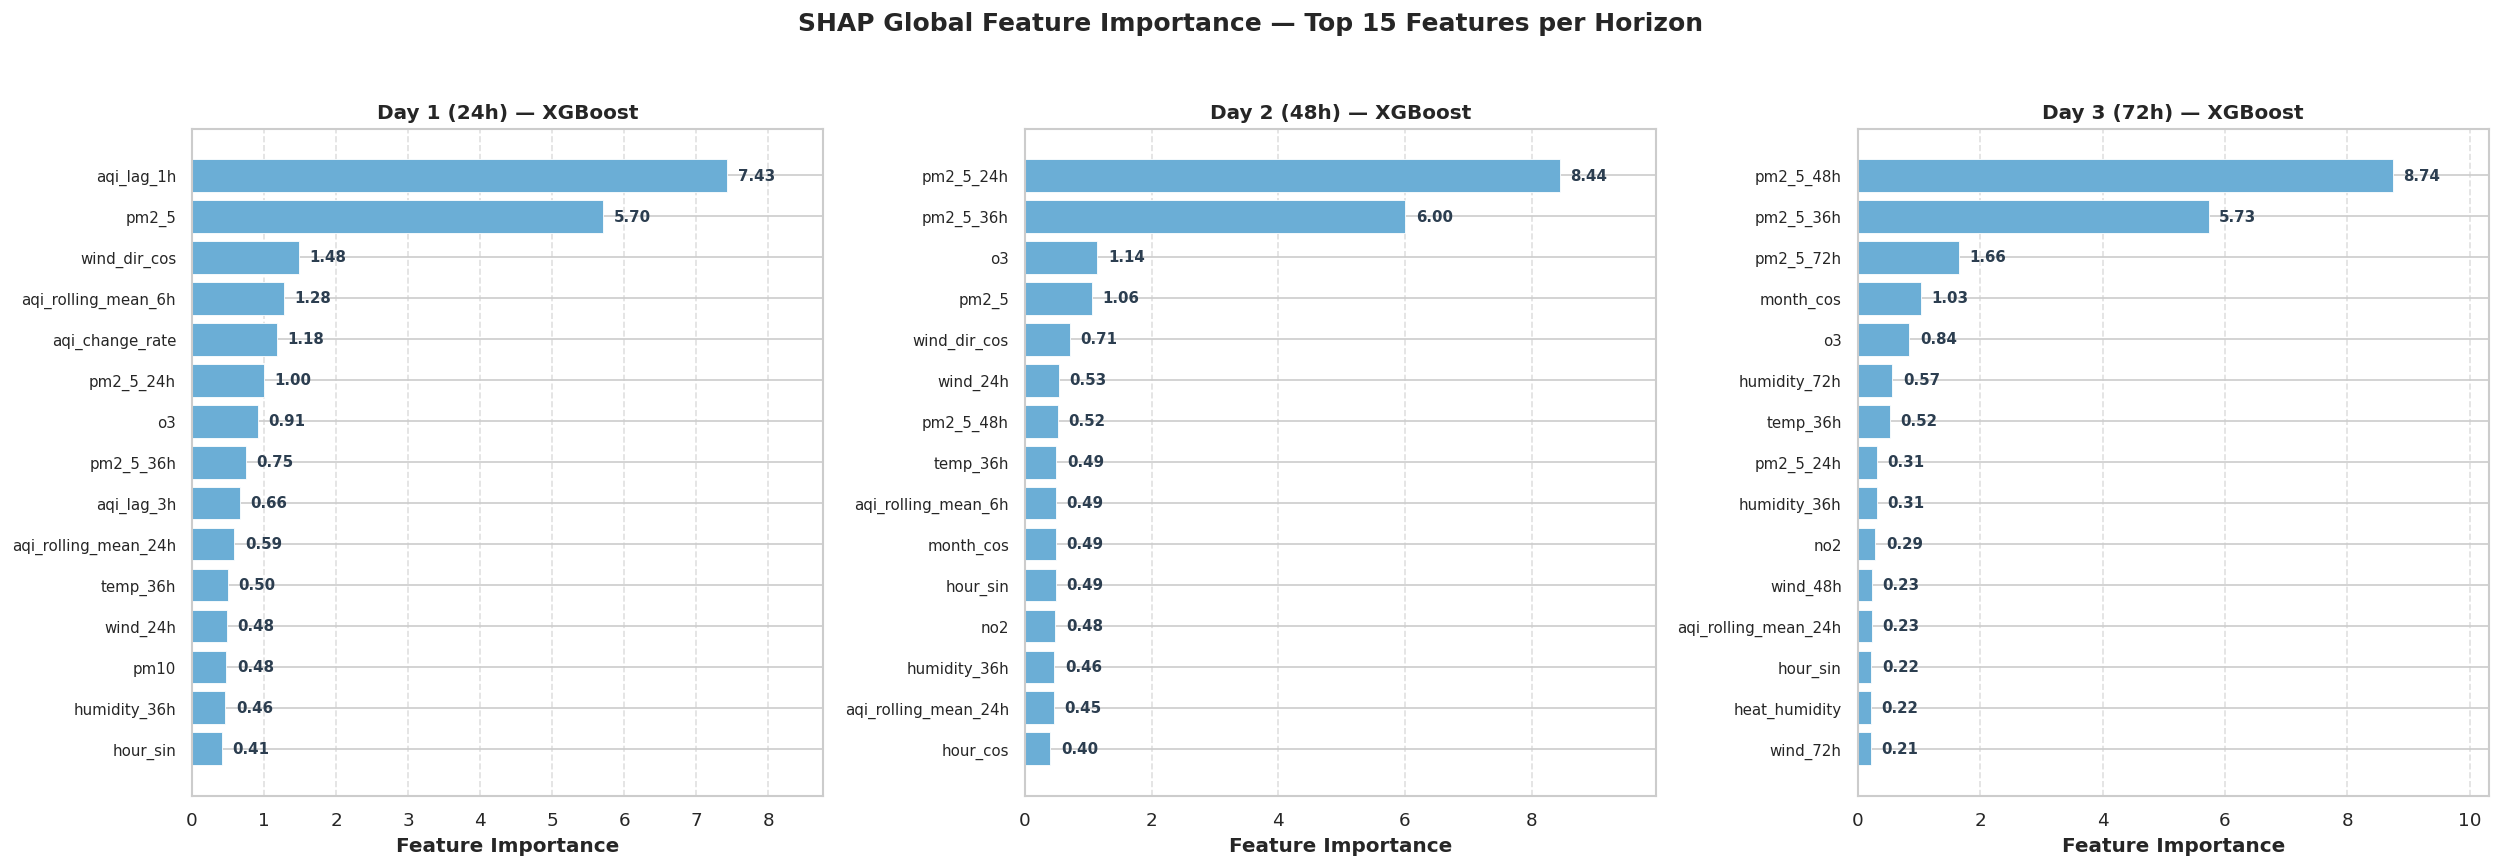

In [23]:
fig, axes = plt.subplots(1, 3, figsize=(21, 7))
 
for i, horizon in enumerate(HORIZONS):
    ax     = axes[i]
    top_df = get_top_features(horizon, n=TOP_N)
 
    # Reverse so highest bar is at top
    values   = top_df["mean_abs_shap"].values[::-1]
    features = top_df["feature"].values[::-1]
 
    bars = ax.barh(
        range(len(top_df)), values,
        color="#6baed6", edgecolor="white", linewidth=0.5
    )
 
    # Value labels on bars
    max_val = values.max()
    for j, val in enumerate(values):
        ax.text(
            val + max_val * 0.02, j,
            f"{val:.2f}",
            va="center", fontsize=9,
            fontweight="bold", color="#2c3e50"
        )
 
    ax.set_yticks(range(len(top_df)))
    ax.set_yticklabels(features, fontsize=9)
    ax.set_title(HORIZON_LABELS[horizon], fontweight="bold", fontsize=12)
    ax.set_xlabel("Feature Importance")
    ax.set_xlim(0, max_val * 1.18)
    ax.grid(axis="x", linestyle="--", alpha=0.6)
 
plt.suptitle(
    "SHAP Global Feature Importance — Top 15 Features per Horizon",
    fontsize=15, fontweight="bold", y=1.03
)
plt.tight_layout()
plt.show()
 

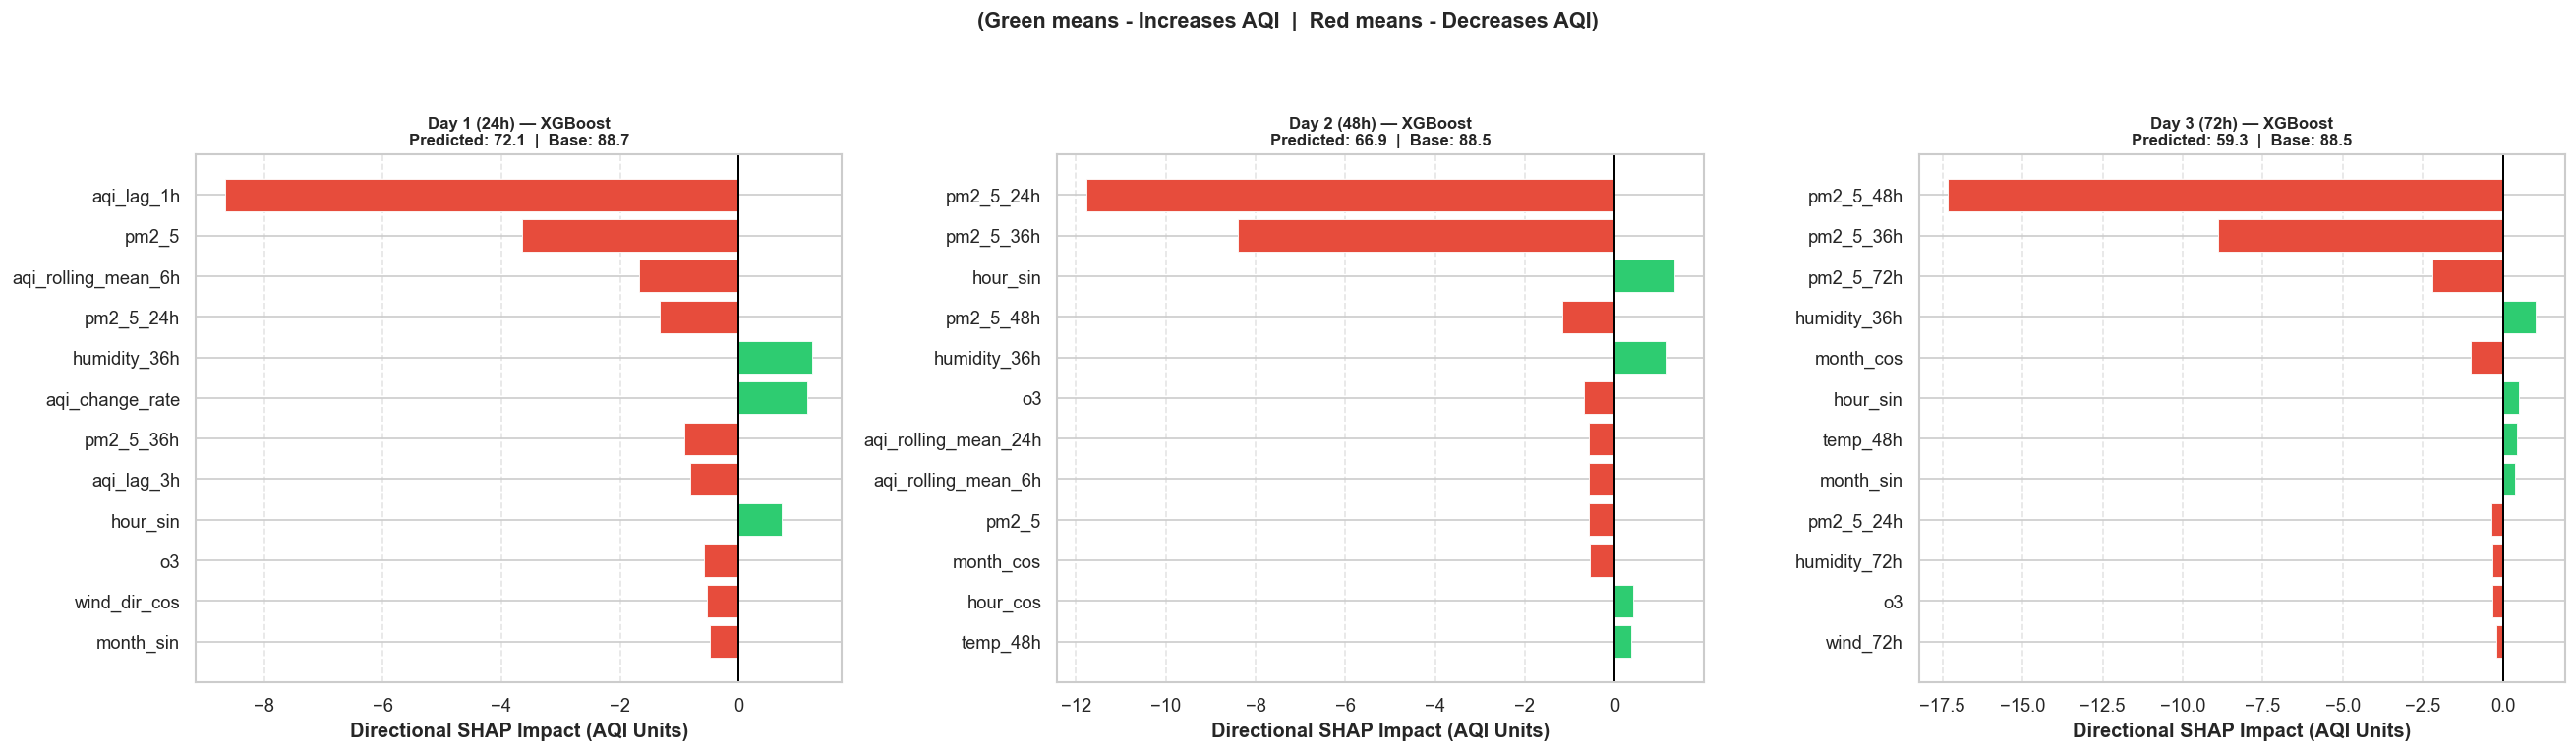

In [26]:
SAMPLE_IDX = 0    # which test sample to explain
POS_COLOR  = "#2ecc71"   # green = pushes AQI up
NEG_COLOR  = "#e74c3c"   # red   = pushes AQI down
TOP_LOCAL  = 12
 
fig, axes = plt.subplots(1, 3, figsize=(22, 6))
 
for i, horizon in enumerate(HORIZONS):
    d  = shap_data[horizon]
    ax = axes[i]
 
    sv         = d["shap_values"][SAMPLE_IDX]      # shape: (n_features,)
    top_idx    = np.argsort(np.abs(sv))[-TOP_LOCAL:]
    feat_names = np.array(d["feat_cols"])[top_idx]
    impacts    = sv[top_idx]
    colors     = [POS_COLOR if x > 0 else NEG_COLOR for x in impacts]
 
    ax.barh(feat_names, impacts, color=colors, edgecolor="white", linewidth=0.5)
    ax.axvline(0, color="black", linewidth=1.2)
 
    pred_val = d["expected_value"] + sv.sum()
    ax.set_title(
        f"{HORIZON_LABELS[horizon]}\n"
        f"Predicted: {pred_val:.1f}  |  Base: {d['expected_value']:.1f}",
        fontsize=10, fontweight="bold"
    )
    ax.set_xlabel("Directional SHAP Impact (AQI Units)")
    ax.grid(axis="x", linestyle="--", alpha=0.5)
 
plt.suptitle(
    f"(Green means - Increases AQI  |  Red means - Decreases AQI)",
    fontsize=13, fontweight="bold", y=1.06
)
plt.tight_layout()
plt.show()

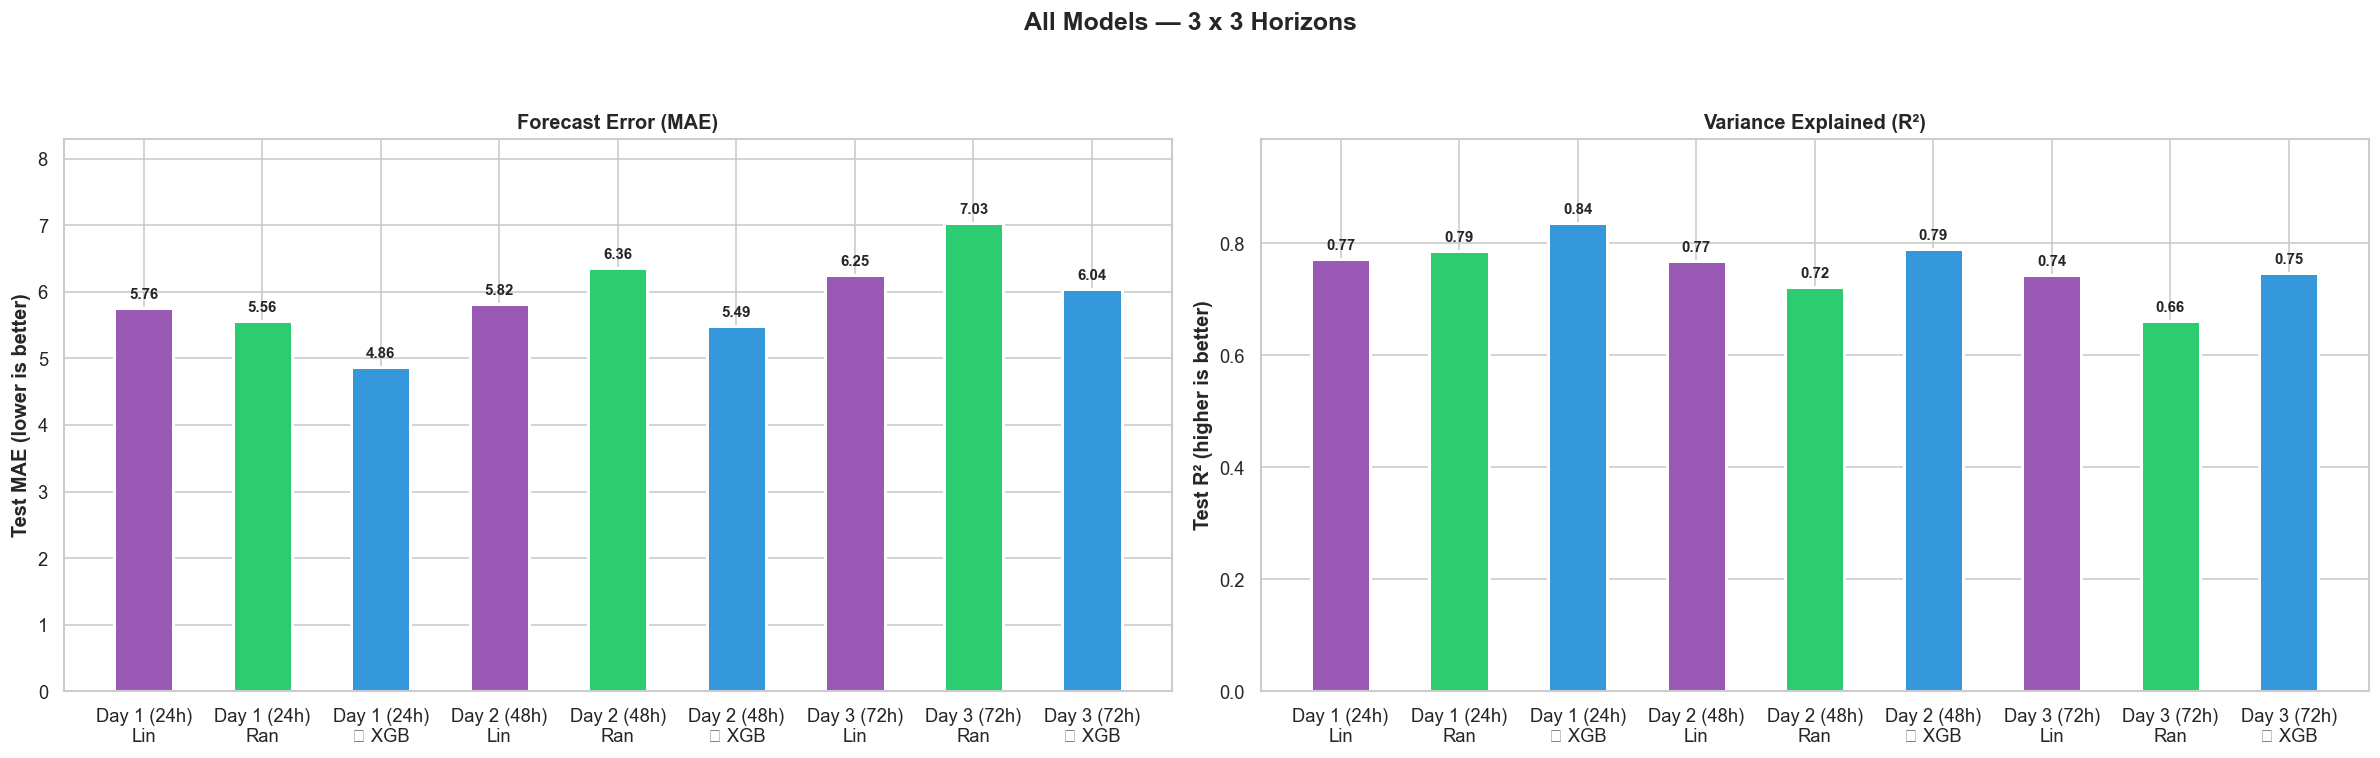


Performance Summary:
   Day 1 (24h) Lin                     | MAE: 5.7595 | R²: 0.7729
   Day 1 (24h) Ran                     | MAE: 5.5600 | R²: 0.7870
   Day 1 (24h) ★ XGB                   | MAE: 4.8645 | R²: 0.8362
   Day 2 (48h) Lin                     | MAE: 5.8190 | R²: 0.7678
   Day 2 (48h) Ran                     | MAE: 6.3645 | R²: 0.7228
   Day 2 (48h) ★ XGB                   | MAE: 5.4940 | R²: 0.7893
   Day 3 (72h) Lin                     | MAE: 6.2461 | R²: 0.7440
   Day 3 (72h) Ran                     | MAE: 7.0323 | R²: 0.6607
   Day 3 (72h) ★ XGB                   | MAE: 6.0440 | R²: 0.7477


In [25]:
import gridfs
import pickle
import matplotlib.patches as mpatches
from sklearn.metrics import mean_absolute_error, r2_score

split_idx = int(len(df) * TRAIN_RATIO)

all_model_names = []
all_colors      = []
all_mae_vals    = []
all_r2_vals     = []

COLOR_MAP = {
    "LinearRegression": "#9b59b6",
    "RandomForest":     "#2ecc71",
    "XGBoost":          "#3498db",
}
BEST_EDGE = "#f39c12"

fs = gridfs.GridFS(db)   # reuse existing client/db from Cell 2

for horizon in HORIZONS:
    target    = f"aqi_{horizon}"
    feat_cols = get_features(horizon)
    day_num   = HORIZONS.index(horizon) + 1

    X_test = df.iloc[split_idx:][feat_cols].values
    y_test = df.iloc[split_idx:][target].values

    horizon_maes  = {}
    horizon_preds = {}

    for model_name in ["LinearRegression", "RandomForest", "XGBoost"]:
        meta = db["models"].find_one({"target": target, "model_name": model_name})
        if not meta:
            continue

        bundle = pickle.loads(fs.get(meta["gridfs_id"]).read())
        model  = bundle["model"]
        scaler = bundle["scaler"]

        X_ready = scaler.transform(X_test) if model_name == "LinearRegression" else X_test
        y_pred  = model.predict(X_ready)

        horizon_maes[model_name]  = mean_absolute_error(y_test, y_pred)
        horizon_preds[model_name] = r2_score(y_test, y_pred)

    best_name = min(horizon_maes, key=horizon_maes.get)

    for model_name in horizon_maes:
        is_best = model_name == best_name
        all_model_names.append(f"Day {day_num} ({horizon})\n{'★ ' if is_best else ''}{model_name[:3]}")
        all_colors.append(COLOR_MAP[model_name])
        all_mae_vals.append(horizon_maes[model_name])
        all_r2_vals.append(horizon_preds[model_name])


# ── Plot ──────────────────────────────────────────────────────
sns.set_theme(style="whitegrid")
fig, (ax0, ax1) = plt.subplots(1, 2, figsize=(20, 6))

for ax, vals, ylabel, title in [
    (ax0, all_mae_vals, "Test MAE (lower is better)", "Forecast Error (MAE)"),
    (ax1, all_r2_vals,  "Test R² (higher is better)",  "Variance Explained (R²)"),
]:
    ax.bar(all_model_names, vals, color=all_colors, width=0.5, linewidth=1.8)
    ax.set_ylabel(ylabel, fontweight="bold")
    ax.set_title(title,   fontweight="bold")
    ax.set_ylim(0, max(vals) * 1.18)
    for i, v in enumerate(vals):
        ax.text(i, v + max(vals) * 0.02, f"{v:.2f}",
                ha="center", fontweight="bold", fontsize=9)


plt.suptitle("All Models — 3 x 3 Horizons", fontsize=15, fontweight="bold", y=1.05)
plt.tight_layout()
plt.show()

print("\nPerformance Summary:")
for i, name in enumerate(all_model_names):
    print(f"   {name.replace(chr(10), ' '):<35} "
          f"| MAE: {all_mae_vals[i]:.4f} | R²: {all_r2_vals[i]:.4f}")